# function and initial and boundary condition
function:$u_{xx}+u_{yy}+k^2u-q(x,y)=0,\\ $
其中$q(x,y)=-(a_1\pi)^2\sin(a_1\pi x)\sin(a_2\pi y)-(a_2\pi)^2\sin(a_1\pi x)\sin(a_2\pi y)+k^2\sin(a_1\pi x)\sin(a_2\pi y) \\$

ic&bc:$u(-1,y)=u(1,y)=u(x,1)=u(x,-1)$

sampling region: $\Omega\times\Omega \\$

analytical solution:$u(x,y)=\sin(a_1\pi x)\sin(a_2\pi y)$
其中$a_1=1,a_2=4,k=1$


# import

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# NN

In [2]:
class FNN(nn.Module):
    def __init__(self, layers, device):
        super(FNN, self).__init__()
        self.func = nn.Tanh  # activation function
        self.layers = layers
        self.device = device
        self.model = self.create_model().to(self.device)

    def create_model(self):
        layers_list = []
        for i in range(len(self.layers) - 1):
            layers_list.append(nn.Linear(self.layers[i], self.layers[i + 1]))
            if i < len(self.layers) - 2:
                layers_list.append(self.func())
        return nn.Sequential(*layers_list)

    def forward(self, X):
        out = self.model(X)
        return out

# Fourier Emcoding

In [3]:
class FourierEncoding(torch.nn.Module):
    def __init__(self, layers, device, L_x=2.0, L_y=2.0, M_x=10, M_y=10):
        super().__init__()
        self.L_x, self.L_y = L_x, L_y
        self.M_x, self.M_y = M_x, M_y
        self.device = device
        dim_x = 2 * M_x
        dim_y = 2 * M_y
        if dim_x != dim_y:
            raise ValueError("傅里叶编码的特征维度必须一致。")

        layers_shared = list(layers)
        layers_shared[0] = dim_x+dim_y
        self.dnn = FNN(layers_shared, device=self.device)

        for param in self.dnn.parameters():
            if param.ndim > 1:
                torch.nn.init.xavier_normal_(param)

        self.k_x = torch.nn.Parameter(torch.arange(1, M_x + 1, dtype=torch.float32, device=device), requires_grad=False)
        self.k_y = torch.nn.Parameter(torch.arange(1, M_y + 1, dtype=torch.float32, device=device), requires_grad=False)

    def encode_xy(self, x,y):
        w_x = 2.0 * np.pi / self.L_x
        w_y = 2.0 * np.pi / self.L_y
        return torch.hstack([
            torch.cos(self.k_x * w_x * x)*torch.cos(self.k_y * w_y * y),
            torch.sin(self.k_x * w_x * x)*torch.cos(self.k_y * w_y * y),
            torch.cos(self.k_x * w_x * x)*torch.sin(self.k_y * w_y * y),
            torch.sin(self.k_x * w_x * x)*torch.sin(self.k_y * w_y * y),
        ])

    def forward(self, H):
        x = H[:, 0:1]
        y = H[:, 1:2]
        feat = self.encode_xy(x,y)
        H = self.dnn(feat)
        return H

# normal pinn

In [ ]:
class normal_pinn():
    def __init__(self, layers, device, use_fourier=False, fourier_kwargs=None):
        self.device = device
        self.layers = layers
        self.use_fourier = use_fourier
        fourier_kwargs = fourier_kwargs or {}

        if self.use_fourier:
            self.net = FourierEncoding(layers, device, **fourier_kwargs)
        else:
            self.net = FNN(layers, device)
            
        self.loss_history = []
        self.loss_compute = None
        
        self.optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=1e-3)
        self.optimizer_lbfgs = torch.optim.LBFGS(
            self.net.parameters(),
            lr=1.0,
            max_iter=1,
            max_eval=50,
            history_size=50,
            tolerance_grad=1e-5,
            tolerance_change=1.0 * np.finfo(float).eps,
            line_search_fn="strong_wolfe"
        )
        self.iter = 0
        self.epochs = 0
        self.loss_history = []

    def configure_scheduler(self, scheme="none"):
        scheme = (scheme or "none").lower()
        self.scheduler_adam = None
        self.scheduler_lbfgs = None
        if scheme == "exp":
            self.scheduler_adam = torch.optim.lr_scheduler.ExponentialLR(self.optimizer_adam, gamma=0.9)
        elif scheme == "plateau":
            self.scheduler_adam = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer_adam, mode="min", factor=0.9, patience=1000, verbose=False, min_lr=1e-6
            )
            self.scheduler_lbfgs = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer_lbfgs, mode="min", factor=0.9, patience=100, verbose=False, min_lr=1e-6
            )

    def net_u(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        u = self.net(inputs)
        return u

    def loss_compute_updata(self, loss_compute, X_bc_train, X_f_train, device, config=None):
        # Helmholtz equation has no IC, so we remove X_ic_train
        self.loss_compute = loss_compute(
            self,
            X_bc_train,
            X_f_train,
            device,
            config,
        )

    def loss(self):
        loss_pde, loss_bc = self.loss_compute.loss_compute()
        total_loss = self.loss_compute.weighted_loss(loss_pde, loss_bc)
        return total_loss, loss_pde, loss_bc

    def train(self, epochs=1000, print_every=100, opt_type='adam', scheduler='none', plot_judge='No', plot_type='none', plot_every=None, save_dir=None):
        self.epochs = epochs
        if plot_every is None:
            plot_every = epochs
        opt_type = (opt_type or "adam").lower()
        
        self.configure_scheduler(scheduler)
        self.net.train()
        
        if opt_type == "adam":
            optimizer = self.optimizer_adam
            scheduler_obj = self.scheduler_adam
            for epoch in range(1, self.epochs + 1):
                optimizer.zero_grad()
                total_loss, loss_pde, loss_bc = self.loss()
                total_loss.backward()
                optimizer.step()
                
                if scheduler_obj is not None:
                    if isinstance(scheduler_obj, torch.optim.lr_scheduler.ReduceLROnPlateau):
                        scheduler_obj.step(total_loss.item())
                    else:
                        scheduler_obj.step()
                
                self.iter += 1
                history_entry = {
                    "epoch": self.iter,
                    "total": total_loss.item(),
                    "pde": loss_pde.item(),
                    "bc": loss_bc.item(),
                    "stage": "adam",
                }
                self.loss_history.append(history_entry)
                
                if print_every and epoch % print_every == 0:
                    print(f"[Adam] Epoch {self.iter}: total={total_loss.item():.4e}, pde={loss_pde.item():.4e}, bc={loss_bc.item():.4e}")
                
                if plot_judge != 'No' and epoch % plot_every == 0:
                    self.loss_compute.point_scater(plot_type=plot_type, save_dir=save_dir, name=f'[Adam]epoch[{epoch}:{self.epochs}]')
        else:
            optimizer = self.optimizer_lbfgs
            scheduler_obj = self.scheduler_lbfgs
            def closure():
                optimizer.zero_grad()
                total_loss, _, _ = self.loss()
                total_loss.backward()
                return total_loss

            for epoch in range(1, self.epochs + 1):
                optimizer.step(closure)
                total_loss, loss_pde, loss_bc = self.loss()
                
                if scheduler_obj is not None:
                    if isinstance(scheduler_obj, torch.optim.lr_scheduler.ReduceLROnPlateau):
                        scheduler_obj.step(total_loss.item())
                    else:
                        scheduler_obj.step()
                        
                self.iter += 1
                history_entry = {
                    "epoch": self.iter,
                    "total": total_loss.item(),
                    "pde": loss_pde.item(),
                    "bc": loss_bc.item(),
                    "stage": "lbfgs",
                }
                self.loss_history.append(history_entry)

                if print_every and epoch % print_every == 0:
                    print(f"[LBFGS] Epoch {self.iter}: total={total_loss.item():.4e}, pde={loss_pde.item():.4e}, bc={loss_bc.item():.4e}")
                
                if plot_judge != 'No' and epoch % plot_every == 0:
                    self.loss_compute.point_scater(plot_type=plot_type, save_dir=save_dir, name=f'[LBFGS]epoch[{epoch}:{self.epochs}]')

        return self.loss_history

    def predict(self, X):
        if isinstance(X, np.ndarray):
            X_tensor = torch.tensor(X, dtype=torch.float32, device=self.device)
        else:
            X_tensor = X.to(self.device)
        x = X_tensor[:, 0:1]
        y = X_tensor[:, 1:2]
        self.net.eval()
        with torch.no_grad():
            u = self.net_u(x, y)
        return u.cpu().numpy()
        
    def save_model(self, file_path):
        """
        保存模型状态、优化器状态和训练历史到指定路径 (.pth)
        """
        # 确保目录存在
        directory = os.path.dirname(file_path)
        if directory and not os.path.exists(directory):
            os.makedirs(directory, exist_ok=True)

        state = {
            'net_state_dict': self.net.state_dict(),
            'optimizer_adam_state_dict': self.optimizer_adam.state_dict(),
            'optimizer_lbfgs_state_dict': self.optimizer_lbfgs.state_dict(),
            'loss_history': self.loss_history,
            'iter': self.iter,
            'layers': self.layers,
            'use_fourier': self.use_fourier
        }
        torch.save(state, file_path)
        print(f"Model saved successfully to {file_path}")

    def load_model(self, file_path):
        """
        从指定路径加载模型
        """
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")
            
        checkpoint = torch.load(file_path, map_location=self.device)
        
        # 检查结构是否匹配 (简单的检查)
        if 'layers' in checkpoint and checkpoint['layers'] != self.layers:
             print("Warning: Loaded model layers do not match current model layers.")

        self.net.load_state_dict(checkpoint['net_state_dict'])
        self.optimizer_adam.load_state_dict(checkpoint['optimizer_adam_state_dict'])
        self.optimizer_lbfgs.load_state_dict(checkpoint['optimizer_lbfgs_state_dict'])
        self.loss_history = checkpoint['loss_history']
        self.iter = checkpoint['iter']
        print(f"Model loaded successfully from {file_path}, current iter: {self.iter}")

# LossCompute

In [5]:
class LossCompute():
    def __init__(self, model, X_bc_train, X_f_train, device, config=None):
        self.model = model
        self.device = device
        self.config = config or {}
        
        # Parameters for Helmholtz
        self.a1 = 1.0
        self.a2 = 4.0
        self.k = 1.0
        
        default_weights = {"pde": 1.0, "bc": 1.0}
        custom_weights = self.config.get("weights", {})
        self.weights = {**default_weights, **custom_weights}
        
        default_pointwise_weights = {"pde": 1.0, "bc": 1.0}
        custom_pointwise_weights = self.config.get('pointwise_weights', {})
        self.pointwise_weights = {**default_pointwise_weights, **custom_pointwise_weights}

        self.x_bc = torch.tensor(X_bc_train[:, 0:1], dtype=torch.float32, device=device, requires_grad=True)
        self.y_bc = torch.tensor(X_bc_train[:, 1:2], dtype=torch.float32, device=device, requires_grad=True)
        # Assuming Dirichlet BC u=0 based on analytical solution
        self.u_bc = torch.tensor(X_bc_train[:, 2:3], dtype=torch.float32, device=device) 

        self.x_f = torch.tensor(X_f_train[:, 0:1], dtype=torch.float32, device=device, requires_grad=True)
        self.y_f = torch.tensor(X_f_train[:, 1:2], dtype=torch.float32, device=device, requires_grad=True)

        self.residual = {'pde': None, 'bc': None}

    def gradient(self, func, var, order=1):
        if order == 1:
            return torch.autograd.grad(
                func, var, grad_outputs=torch.ones_like(func),
                retain_graph=True, create_graph=True
            )[0]
        else:
            out = self.gradient(func, var)
            return self.gradient(out, var, order - 1)
        
    def _resolve_weight(self, key):
        weight = self.weights.get(key, 1.0)
        if callable(weight): weight = weight()
        if not torch.is_tensor(weight):
            weight = torch.as_tensor(weight, dtype=torch.float32, device=self.device)
        return weight
    
    def _resolve_pointwise_weight(self, key, ref_tensor):
        weight = self.pointwise_weights.get(key, 1.0)
        if callable(weight): weight = weight()
        if not torch.is_tensor(weight):
            weight = torch.as_tensor(weight, dtype=torch.float32, device=self.device)
        if weight.ndim == 0 and ref_tensor is not None:
            weight = weight.expand_as(ref_tensor)
        return weight
    
    def q_source(self, x, y):
        # q(x,y) derived from analytical solution u = sin(a1*pi*x)*sin(a2*pi*y)
        # u_xx + u_yy + k^2*u = q
        # q = (k^2 - (a1*pi)^2 - (a2*pi)^2) * u
        term = (self.k**2 - (self.a1 * np.pi)**2 - (self.a2 * np.pi)**2)
        return term * torch.sin(self.a1 * np.pi * x) * torch.sin(self.a2 * np.pi * y)

    def loss_pde(self):
        self.x_f.requires_grad_(True)
        self.y_f.requires_grad_(True)
        x = self.x_f
        y = self.y_f
        u = self.model.net_u(x, y)
        
        u_x = self.gradient(u, x)
        u_xx = self.gradient(u_x, x)
        u_y = self.gradient(u, y)
        u_yy = self.gradient(u_y, y)
        
        q = self.q_source(x, y)
        
        # Helmholtz: u_xx + u_yy + k^2*u - q = 0
        residual = u_xx + u_yy + self.k**2 * u - q
        
        self.residual['pde'] = residual.abs().detach()
        weight = self._resolve_pointwise_weight('pde', x)
        residual = weight * residual
        return torch.mean(residual**2)

    def loss_bc(self):
        # Dirichlet BC: u = 0 on boundary (derived from analytical solution)
        u_pred = self.model.net_u(self.x_bc, self.y_bc)
        residual = (u_pred - self.u_bc).abs().detach()
        self.residual['bc'] = residual
        
        weight = self._resolve_pointwise_weight('bc', self.x_bc)
        bc_err = weight * (u_pred - self.u_bc)
        return torch.mean(bc_err**2)

    def weighted_loss(self, loss_pde, loss_bc):
        w_pde = self._resolve_weight("pde")
        w_bc = self._resolve_weight("bc")
        return w_pde * loss_pde + w_bc * loss_bc

    def loss_compute(self):
        loss_pde = self.loss_pde()
        loss_bc = self.loss_bc()
        return loss_pde, loss_bc
    
    def up_data(self, X_f_new):  
        self.x_f = torch.tensor(X_f_new[:, 0:1], dtype=torch.float32, device=self.device)
        self.y_f = torch.tensor(X_f_new[:, 1:2], dtype=torch.float32, device=self.device)
        self.x_f.requires_grad_(True)
        self.y_f.requires_grad_(True)

    def updata_config(self, config):
        self.config = config
        default_weights = {"pde": 1.0, "bc": 1.0}
        custom_weights = self.config.get("weights", {})
        self.weights = {**default_weights, **custom_weights}
        default_pointwise_weights = {"pde": 1.0, "bc": 1.0}
        custom_pointwise_weights = self.config.get('pointwise_weights', {})
        self.pointwise_weights = {**default_pointwise_weights, **custom_pointwise_weights}

    def point_scater(self, plot_type='none', cmap='viridis', f_s=1, bc_s=1, save_dir=None, name=None):
        plt.figure(figsize=(6, 6))
        x_f = self.x_f.detach().cpu().numpy().ravel()
        y_f = self.y_f.detach().cpu().numpy().ravel()
        x_bc = self.x_bc.detach().cpu().numpy().ravel()
        y_bc = self.y_bc.detach().cpu().numpy().ravel()

        if plot_type == 'weighted':
            w_f = self._resolve_pointwise_weight('pde', self.x_f)
            w_bc = self._resolve_pointwise_weight('bc', self.x_bc)
            
            w_f = w_f.detach().cpu().numpy().ravel() if torch.is_tensor(w_f) else np.asarray(w_f).ravel()
            w_bc = w_bc.detach().cpu().numpy().ravel() if torch.is_tensor(w_bc) else np.asarray(w_bc).ravel()
            
            arrs = [a for a in (w_f, w_bc) if a is not None and a.size > 0]
            if not arrs: raise RuntimeError("No weights available for plotting.")
            vmin, vmax = min(a.min() for a in arrs), max(a.max() for a in arrs)
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

            plt.scatter(x_f, y_f, c=w_f, cmap=cmap, norm=norm, s=f_s, marker='o', alpha=0.9, label='collocation')
            plt.scatter(x_bc, y_bc, c=w_bc, cmap=cmap, norm=norm, s=bc_s, marker='x', linewidths=1.0, label='BC')
            
            sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
            sm.set_array(np.concatenate([a.ravel() for a in arrs]))
            cbar = plt.colorbar(sm,ax=plt.gca())
            cbar.set_label('w')
        else:
            plt.scatter(x_f, y_f, s=f_s, marker='o', alpha=0.9, label='collocation')
            plt.scatter(x_bc, y_bc, s=bc_s, marker='x', color='r', linewidths=1.0, label='BC')
            
        plt.xlabel('x'); plt.ylabel('y')
        plt.title('Points Scatter')
        plt.legend(loc='best')
        plt.tight_layout()
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(os.path.join(save_dir, f"{name}_sample_location.png"), dpi=300)
        plt.show()
        plt.close()

# loss & visualize

In [6]:
def plot_loss_history(training_history, title="Training loss history", save_path=None):
    if not training_history:
        raise ValueError("training_history is empty.")
    epochs = np.array([entry["epoch"] for entry in training_history])
    loss_total = [entry["total"] for entry in training_history]
    loss_pde = [entry["pde"] for entry in training_history]
    loss_bc = [entry["bc"] for entry in training_history]
    lbfgs_start = next((entry["epoch"] for entry in training_history if entry.get("stage") == "lbfgs"), None)

    plt.figure(figsize=(8, 4))
    plt.semilogy(epochs, loss_total, label="total")
    plt.semilogy(epochs, loss_pde, label="pde")
    plt.semilogy(epochs, loss_bc, label="bc")

    if lbfgs_start is not None:
        plt.axvline(lbfgs_start, color="k", linestyle="--", alpha=0.4)
        plt.text(lbfgs_start, max(loss_total), " LBFGS", va="bottom", ha="left", fontsize=9, color="k")

    plt.xlabel("Iteration")
    plt.ylabel("Loss (log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300)
    plt.show()

def analytical_solution(x, y, a1=1, a2=4):
    return np.sin(a1 * np.pi * x) * np.sin(a2 * np.pi * y)

def plot_solution_comparison(model, x_plot, y_plot, title_prefix="PINN", save_dir=None):
    X_grid, Y_grid = np.meshgrid(x_plot, y_plot)
    XY = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
    
    U_pred = model.predict(XY).reshape(X_grid.shape)
    U_ref = analytical_solution(X_grid, Y_grid)
    U_error = U_pred - U_ref
    abs_error = np.abs(U_error)
    diff = (U_pred - U_ref).ravel()
    abs_l2 = np.linalg.norm(diff)                      # ||U_pred - U_ref||_2
    ref_l2 = np.linalg.norm(U_ref.ravel())
    l2_error = abs_l2/(ref_l2 + 1e-12)
    max_error = np.max(abs_error)
    print(f"{title_prefix} -> L2 error: {l2_error:.4e}, max abs error: {max_error:.4e}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    pcm0 = axes[0].pcolormesh(x_plot, y_plot, U_pred, shading="auto", cmap="RdBu_r")
    axes[0].set_title(f"{title_prefix} prediction")
    axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
    fig.colorbar(pcm0, ax=axes[0], label="u(x, y)")

    pcm1 = axes[1].pcolormesh(x_plot, y_plot, U_ref, shading="auto", cmap="RdBu_r")
    axes[1].set_title("Analytical solution")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    fig.colorbar(pcm1, ax=axes[1], label="u(x, y)")

    pcm2 = axes[2].pcolormesh(x_plot, y_plot, abs_error, shading="auto", cmap="viridis")
    axes[2].set_title(f"Absolute error")
    axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
    fig.colorbar(pcm2, ax=axes[2], label="|error|")

    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, f"{title_prefix}_comparison.png"), dpi=300)
    plt.show()

# Save Log Function

In [7]:
def save_log(save_dir,training_history):
    md_path = f"{save_dir}/train_epochs.md"
    os.makedirs(os.path.dirname(md_path) or ".", exist_ok=True)
    with open(md_path, "w", encoding="utf-8") as f:
        f.write("# 训练 Epoch 日志\n\n")
        f.write("| epoch | stage | total | pde | bc |\n")
        f.write("|---:|:---:|---:|---:|---:|\n")
        for e in training_history:
            if e['epoch']%10000 == 0:
                f.write(f"| {e['epoch']} | {e.get('stage','')} | {e['total']:.4e} | {e['pde']:.4e} | {e['bc']:.4e} |\n")
    print(f"Saved epoch log to {md_path}")
            

In [8]:
np.random.seed(1234)
torch.manual_seed(1234)
rng = np.random.default_rng(1234)

def latin_hypercube_sampling(bounds, n_samples, rng):
    dim = len(bounds)
    result = np.zeros((n_samples, dim))
    cut = np.linspace(0, 1, n_samples + 1)
    for i, (low, high) in enumerate(bounds):
        u = rng.random(n_samples)
        pts = cut[:-1] + u * (cut[1:] - cut[:-1])
        rng.shuffle(pts)
        result[:, i] = low + pts * (high - low)
    return result

# Boundary Conditions: 4 sides of the square [-1, 1] x [-1, 1]
N_bc_side = 200
# Left (-1, y)
y_bc = latin_hypercube_sampling([(-1.0, 1.0)], N_bc_side, rng)
x_left = -np.ones_like(y_bc)
bc_left = np.hstack([x_left, y_bc])
# Right (1, y)
x_right = np.ones_like(y_bc)
bc_right = np.hstack([x_right, y_bc])
# Bottom (x, -1)
x_bc = latin_hypercube_sampling([(-1.0, 1.0)], N_bc_side, rng)
y_bottom = -np.ones_like(x_bc)
bc_bottom = np.hstack([x_bc, y_bottom])
# Top (x, 1)
y_top = np.ones_like(x_bc)
bc_top = np.hstack([x_bc, y_top])

X_bc_points = np.vstack([bc_left, bc_right, bc_bottom, bc_top])
# Analytical solution on boundary is 0
U_bc_values = analytical_solution(X_bc_points[:, 0:1], X_bc_points[:, 1:2])
X_bc_train = np.hstack([X_bc_points, U_bc_values])

# Collocation Points
N_f = 1200
X_f_train = latin_hypercube_sampling([(-1.0, 1.0), (-1.0, 1.0)], N_f, rng)

current train model:PINN-Norm
Using device cuda


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Adam] Epoch 10000: total=1.4743e+00, pde=1.4557e+00, bc=1.8606e-02
[Adam] Epoch 20000: total=2.2911e-01, pde=2.2011e-01, bc=8.9984e-03
[LBFGS] Epoch 21000: total=2.8318e-04, pde=1.2364e-04, bc=1.5955e-04
[LBFGS] Epoch 22000: total=2.8318e-04, pde=1.2364e-04, bc=1.5955e-04
Model saved successfully to Helmholtz/PINN-Norm/PINN-Norm.pth


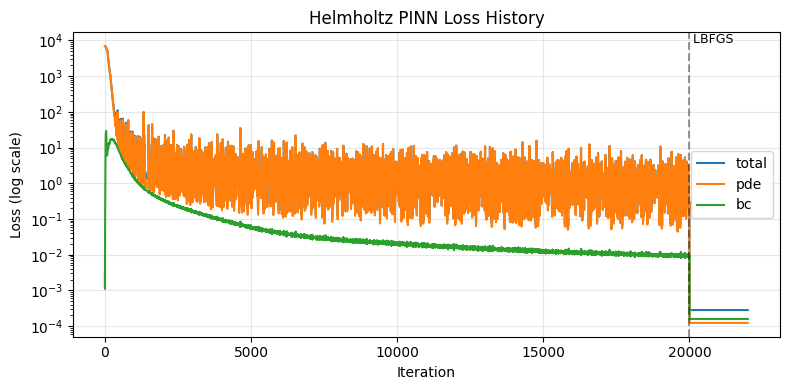

Helmholtz -> L2 error: 7.1581e-03, max abs error: 5.4360e-02


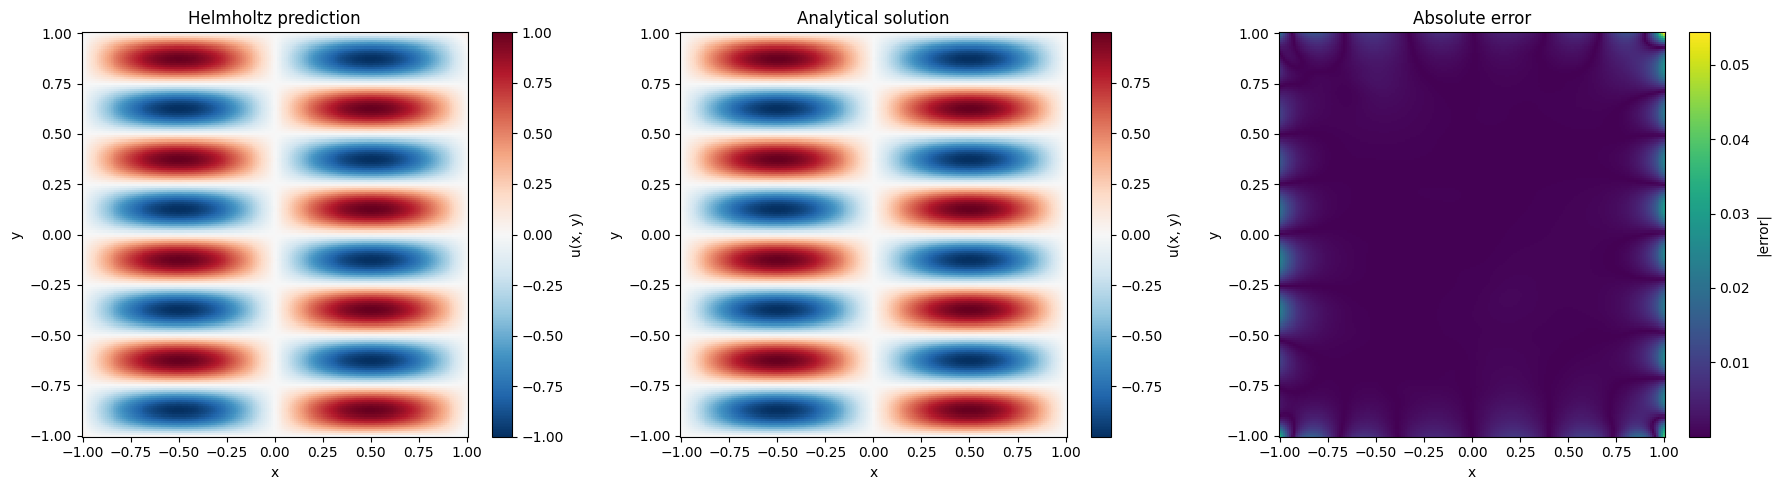

In [9]:
model = 'PINN-Norm'
print(f'current train model:{model}')
save_dir = 'Helmholtz/' + model
layers = [2, 128, 128, 128, 128, 1]
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f'Using device {device}')
# epochs = 20000
pinn_norm = normal_pinn(
    layers=layers,
    device=device,
    use_fourier=False # Optional: Set to True if needed
)

pinn_norm.loss_compute_updata(LossCompute, X_bc_train, X_f_train, device)

loss_config = {'weights': {'pde': 1, 'bc': 1}}
pinn_norm.loss_compute.updata_config(loss_config)

# Adam Training
training_history = pinn_norm.train(
    epochs=20000,
    print_every=10000,
    opt_type='adam',
    scheduler='none',
    # plot_judge='Yes',
    # plot_every=1000,
    # plot_type='weighted',
    # save_dir="results/helmholtz"
)

# LBFGS Training
training_history = pinn_norm.train(
    epochs=2000,
    print_every=1000,
    opt_type='lbfgs',
    scheduler='none',
    # plot_judge='Yes',
    # plot_every=1000,
    # plot_type='weighted',
    # save_dir="results/helmholtz_norm"
)
# save model 
save_path = f"{save_dir}/{model}.pth"
pinn_norm.save_model(save_path)

# Loss Log
plot_loss_history(
    training_history,
    title="Helmholtz PINN Loss History",
    save_path=f"{save_dir}/loss_history.png",
)

# Visualize
x_plot = np.linspace(-1, 1, 200)
y_plot = np.linspace(-1, 1, 200)
plot_solution_comparison(
    model=pinn_norm,
    x_plot=x_plot,
    y_plot=y_plot,
    title_prefix="Helmholtz",
    save_dir=save_dir,
)

In [11]:
# layers = [2, 128, 128, 128, 128, 1]
# device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
# fourier_kwargs = {"L_x":2.0, "M_x": 5,"L_y":2.0, "M_y": 5}
# print(f'Using device {device}')
# epochs = 300000
# pinn_norm_fourier = normal_pinn(
#     layers=layers,
#     device=device,
#     use_fourier=True,
#     fourier_kwargs = fourier_kwargs,
# )

# pinn_norm_fourier.loss_compute_updata(LossCompute, X_bc_train, X_f_train, device)

# loss_config = {'weights': {'pde': 1, 'bc': 100}}
# pinn_norm_fourier.loss_compute.updata_config(loss_config)

# # Adam Training
# training_history = pinn_norm_fourier.train(
#     epochs=300000,
#     print_every=10000,
#     opt_type='adam',
#     scheduler='plateau',
#     # plot_judge='Yes',
#     # plot_every=1000,
#     # plot_type='weighted',
#     # save_dir="results/helmholtz"
# )

# # LBFGS Training
# training_history = pinn_norm_fourier.train(
#     epochs=1000,
#     print_every=100,
#     opt_type='lbfgs',
#     scheduler='plateau',
#     # plot_judge='Yes',
#     # plot_every=1000,
#     # plot_type='weighted',
#     # save_dir="results/helmholtz_norm"
# )

# # Loss Log
# plot_loss_history(
#     training_history,
#     title="Helmholtz PINN Loss History",
#     save_path="results/helmholtz/pinn_norm_fourier/loss_history.png",
# )

# # Visualize
# x_plot = np.linspace(-1, 1, 200)
# y_plot = np.linspace(-1, 1, 200)
# plot_solution_comparison(
#     model=pinn_norm_fourier,
#     x_plot=x_plot,
#     y_plot=y_plot,
#     title_prefix="Helmholtz",
#     save_dir="results/helmholtz/pinn_norm_fourier",
# )

# weight function

In [ ]:
# def omega_weight(model, target, alpha=1, beta=1):
#     device = getattr(model, 'device', torch.device('cpu'))
#     target = (target or '').lower()
#     base_target = target.split(':', 1)[0]
#     cache = {"w": None}

#     def factory():
#         loss_compute = getattr(model, "loss_compute", None)
#         if loss_compute is None:
#             raise AttributeError("LossCompute 尚未初始化，无法计算权重。")
        
#         residual_store = loss_compute.residual.get(base_target)
#         if residual_store is None:
#             raise RuntimeError(f"尚未为 {base_target} 计算 residual。")

#         with torch.no_grad():
#             residual_abs = residual_store.detach()
#             r_median = torch.median(residual_abs)
#             r_mad = torch.median(torch.abs(residual_abs - r_median)) + 1e-8
#             r_normalized = (residual_abs - r_median) / r_mad
#             gamma = torch.quantile(r_normalized, 0.75)
#             s = 1 + alpha * torch.sigmoid((r_normalized - gamma) * beta)
#             w = s / (s.mean() + 1e-8)
#             cache["w"] = w
#         return cache["w"]
        
#     return factory, cache

In [27]:
def omega_weight(model, target, alpha=1, beta=1):
        # def omega_weight(model, target, w_max = 10.0, w_min = 1,alpha=1,beta=1):
    '''
    args:
        model:传入模型
        w_max,w_min表示大小权重的差距,并非真实的权重值
        alpha表示最大变化范围
        beta改变陡峭程度
    note:
        固定alpha,beta超参数
    '''
    device = getattr(model, 'device', torch.device('cpu'))
    target = (target or '').lower()
    parts = target.split(':', 1)
    base_target = parts[0]
    bc_component = parts[1] if len(parts) > 1 else None

    def factory():
        loss_compute = getattr(model, "loss_compute", None)
        if loss_compute is None:
            raise AttributeError("LossCompute 尚未初始化，无法计算权重。")
        
        residual_store = loss_compute.residual.get(base_target)
        if residual_store is None:
            raise RuntimeError(f"尚未为 {base_target} 计算 residual, 无法生成权重。请先执行对应的 loss 计算。")

        residual_abs = residual_store

        with torch.no_grad():
            residual_abs = residual_abs.detach()
            r_median = torch.median(residual_abs)
            # MAD = median(|x - median|)
            r_mad = torch.median(torch.abs(residual_abs - r_median)) + 1e-8
            r_normalized = (residual_abs - r_median) / r_mad
            # TODO 调整关注的中心
            gamma = torch.quantile(r_normalized, 0.75)
                                    
            # beta = beta   # 先固定陡峭程度，后去更改为可训练参数

            s = 1 + alpha*torch.sigmoid((r_normalized - gamma)*beta)
            # s = alpha*torch.sigmoid((r_normalized - gamma)*beta)
            w = s
            w = w/(w.mean() + 1e-8)
        return w
        
    return factory

# weighted train

In [ ]:
# model_name = 'RNF-1-10-75'
# print(f'current train model:{model_name}')
# save_dir = 'Helmholtz/' + model_name
# layers = [2, 128, 128, 128, 128, 1]
# device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
# print(f'Using device {device}')

# alpha = 10
# beta  = 1

# pinn_curr = normal_pinn(layers=layers, device=device)
# pinn_curr.loss_compute_updata(LossCompute, X_bc_train, X_f_train, device)

# # ── Adam 阶段：权重动态更新 ───────────────────────────────
# pde_weight_fn, weight_cache = omega_weight(pinn_curr, "pde", alpha, beta)

# loss_config_adam = {
#     'weights': {'bc': 100},
#     'pointwise_weights': {'pde': pde_weight_fn},
# }
# pinn_curr.loss_compute.updata_config(loss_config_adam)

# training_history = pinn_curr.train(
#     epochs=20000,
#     print_every=10000,
#     opt_type='adam',
#     scheduler='plateau',
#     plot_judge='Yes',
#     plot_every=10000,
#     plot_type='weighted',
#     save_dir=f"{save_dir}/sample_weight&location",
# )

# # ── Adam 结束后冻结权重 ───────────────────────────────────
# # assert weight_cache["w"] is not None, "Adam 阶段未生成权重，请检查残差是否正常计算。"
# # frozen_w = weight_cache["w"].clone().detach()
# # print(f"frozen weight | min={frozen_w.min():.4f}, max={frozen_w.max():.4f}, mean={frozen_w.mean():.4f}")

# # loss_config_lbfgs = {
# #     'weights': {'bc': 100},
# #     'pointwise_weights': {'pde': lambda: frozen_w},  # 真正的常数，不再更新
# # }
# loss_config_lbfgs = {
#     'weights': {'bc': 100},
#     'pointwise_weights': {'pde': 1},  # 真正的常数，不再更新
# }
# pinn_curr.loss_compute.updata_config(loss_config_lbfgs)

# # ── LBFGS 阶段：权重固定 ──────────────────────────────────
# training_history = pinn_curr.train(
#     epochs=2000,
#     print_every=1000,
#     opt_type='lbfgs',
#     scheduler='plateau',
#     plot_judge='Yes',
#     plot_every=1000,
#     plot_type='weighted',
#     save_dir=f"{save_dir}/sample_weight&location",
# )

# # ── 保存 & 可视化 ─────────────────────────────────────────
# pinn_curr.save_model(f"{save_dir}/{model_name}.pth")

# plot_loss_history(
#     training_history,
#     title="Helmholtz RNF Loss History",
#     save_path=f"{save_dir}/{model_name}.png",
# )

# x_plot = np.linspace(-1, 1, 200)
# y_plot = np.linspace(-1, 1, 200)
# plot_solution_comparison(
#     model=pinn_curr,
#     x_plot=x_plot,
#     y_plot=y_plot,
#     title_prefix="Helmholtz",
#     save_dir=save_dir,
# )

# save_log(save_dir, training_history)

current train model:RNF-1-10-75
Using device cuda


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Adam] Epoch 10000: total=4.0671e-01, pde=3.2990e-01, bc=7.6814e-04


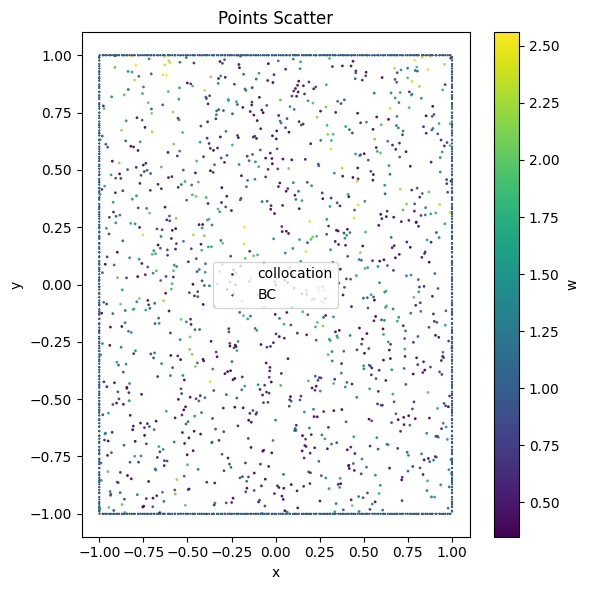

[Adam] Epoch 20000: total=5.7221e-02, pde=4.0136e-02, bc=1.7086e-04


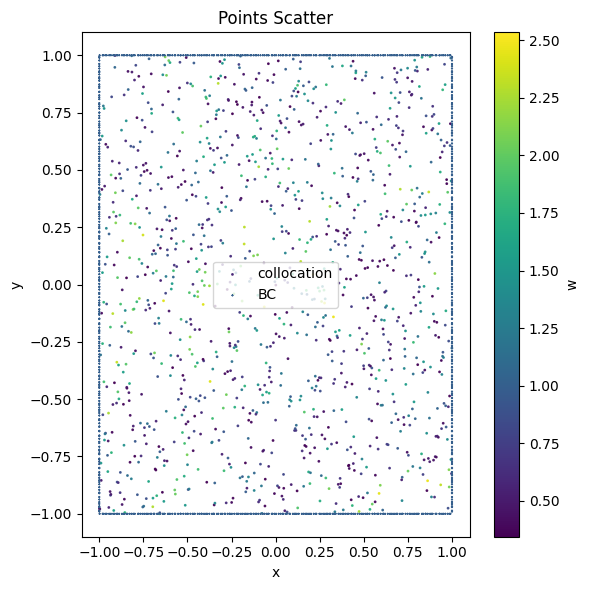

[LBFGS] Epoch 21000: total=2.3839e-04, pde=2.0307e-04, bc=3.5315e-07


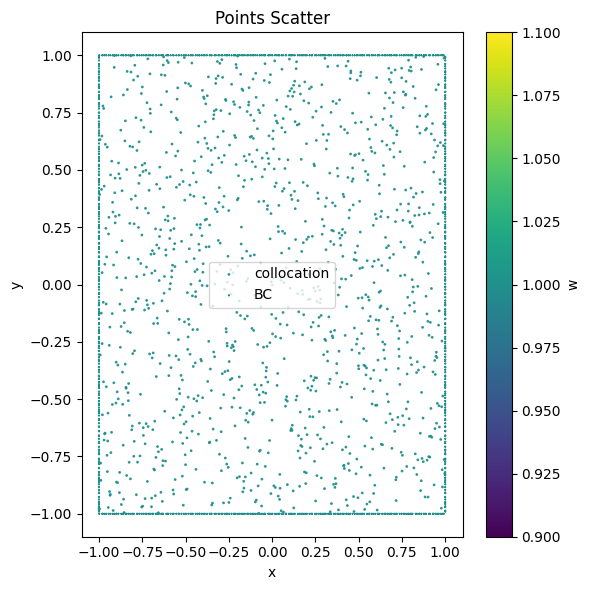

[LBFGS] Epoch 22000: total=2.3838e-04, pde=2.0307e-04, bc=3.5315e-07


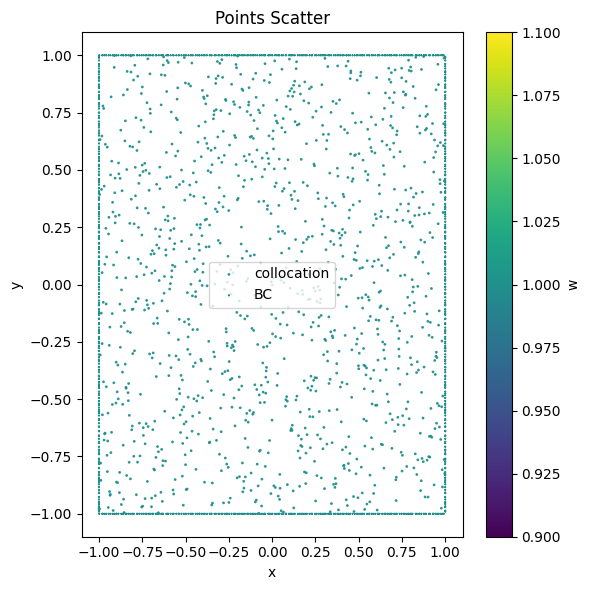

Model saved successfully to Helmholtz/RNF-1-10-75/RNF-1-10-75.pth


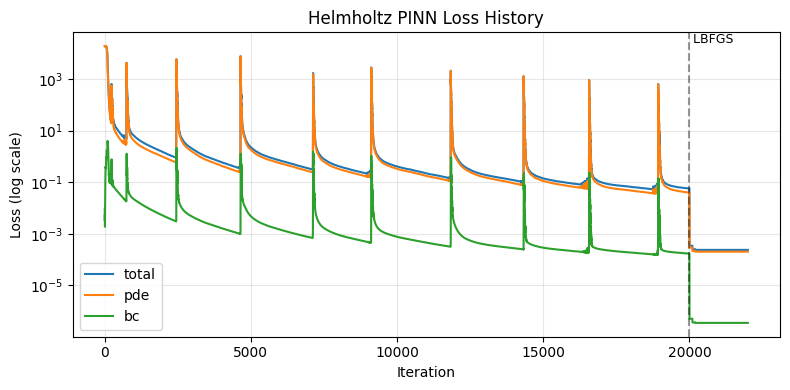

Helmholtz -> L2 error: 6.1251e-04, max abs error: 1.4540e-03


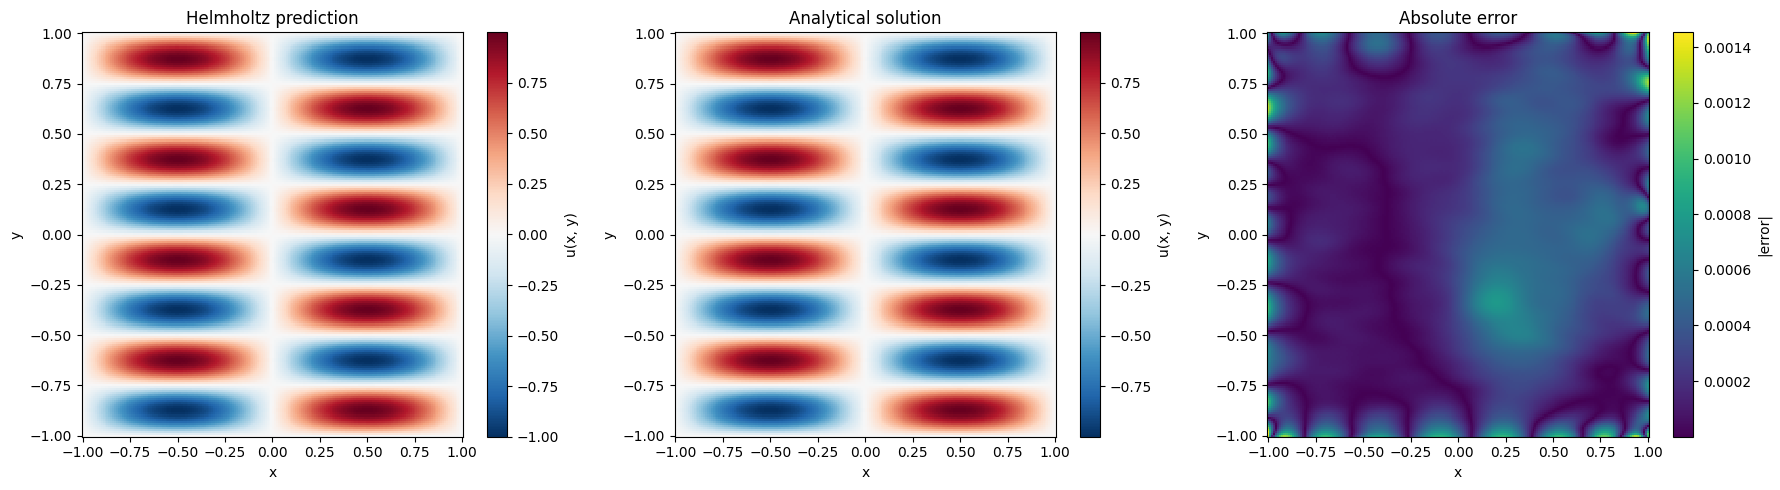

Saved epoch log to Helmholtz/RNF-1-10-75/train_epochs.md


In [31]:
model = 'RNF-1-10-75'
print(f'current train model:{model}')
save_dir = 'Helmholtz/' + model
layers = [2,128,128,128,128,1]
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
# fourier_kwargs = {"L_x":2.0, "M_x": 5,"L_y":2.0, "M_y": 5}
print(f'Using device {device}')
epochs = 20000
alpha = 10
beta = 1
pinn_curr = normal_pinn(
    layers = layers,
    device = device,
    # use_fourier = True,
    # fourier_kwargs = fourier_kwargs,
)
pinn_curr.loss_compute_updata(LossCompute,X_bc_train,X_f_train,device)

pde_weight = omega_weight(pinn_curr, "pde", alpha, beta)
# bc_omega_weight = omega_weight(pinn_curr,target='bc',tau=tau,gamma=gamma)
# ic_omega_weight = omega_weight(pinn_curr,target='ic',tau=tau,gamma=gamma)

loss_config = { # 'weights':{'pde':lambda_pde,'bc':lambda_bc,'ic':lambda_ic},
                'weights': {'pde': 1, 'bc': 100},
                'pointwise_weights':{
                               'pde':pde_weight,
                                },
               }

pinn_curr.loss_compute.updata_config(loss_config)

training_history = pinn_curr.train(
    epochs=epochs,
    print_every=10000,
    opt_type= 'adam',
    scheduler='plateau',
    plot_judge = 'Yes',
    plot_every = 10000,
    plot_type = 'weighted',
    save_dir=f"{save_dir}/sample_weight&location",
)

loss_config = { # 'weights':{'pde':lambda_pde,'bc':lambda_bc,'ic':lambda_ic},
                'weights': {'pde': 1, 'bc': 100},
                'pointwise_weights':{
                               'pde':1,
                                },
               }

pinn_curr.loss_compute.updata_config(loss_config)

training_history = pinn_curr.train(
    epochs=2000,
    print_every=1000,
    opt_type='lbfgs',
    scheduler='plateau',
    plot_judge='Yes',
    plot_every = 1000,
    plot_type = 'weighted',
    save_dir=f"{save_dir}/sample_weight&location",
)

# save model
save_path = f"{save_dir}/{model}.pth"
pinn_curr.save_model(save_path)

# Loss Log
plot_loss_history(
    training_history,
    title="Helmholtz PINN Loss History",
    save_path=f"{save_dir}/{model}.png",
)

# Visualize
x_plot = np.linspace(-1, 1, 200)
y_plot = np.linspace(-1, 1, 200)
plot_solution_comparison(
    model=pinn_curr,
    x_plot=x_plot,
    y_plot=y_plot,
    title_prefix="Helmholtz",
    save_dir=save_dir,
)

# save log
save_log(save_dir,training_history)

In [ ]:
# layers = [2,128,128,128,128,1]
# device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
# fourier_kwargs = {"L_x":2.0, "M_x": 5,"L_y":2.0, "M_y": 5}
# print(f'Using device {device}')
# epochs = 300000
# tau = 10       # 表示温度的起始值
# gamma = 5.0   # 表示权重的最大值
# pinn_curr_fourier = normal_pinn(
#     layers = layers,
#     device = device,
#     use_fourier = True,
#     fourier_kwargs = fourier_kwargs,
# )
# pinn_curr_fourier.loss_compute_updata(LossCompute,X_bc_train,X_f_train,device)

# pde_omega_weight = omega_weight(pinn_curr,target='pde',tau=tau,gamma=gamma)
# # bc_omega_weight = omega_weight(pinn_curr,target='bc',tau=tau,gamma=gamma)
# # ic_omega_weight = omega_weight(pinn_curr,target='ic',tau=tau,gamma=gamma)

# loss_config = {# 'weights':{'pde':lambda_pde,'bc':lambda_bc,'ic':lambda_ic},
#                 'weights':{'bc':100},
#                'pointwise_weights':{
#                    'pde':pde_omega_weight,
#                     },
#                }

# pinn_curr_fourier.loss_compute.updata_config(loss_config)

# training_history = pinn_curr_fourier.train(
#     epochs=epochs,
#     print_every=10000,
#     opt_type= 'adam',
#     scheduler='plateau',
#     plot_judge = 'Yes',
#     plot_every = 10000,
#     plot_type = 'weighted',
#     save_dir="helmholtz/pinn_MAD_bc100_fourier/sample_weight&location",
# )
# training_history = pinn_curr_fourier.train(
#     epochs=1000,
#     print_every=100,
#     opt_type='lbfgs',
#     scheduler='plateau',
#     plot_judge='Yes',
#     plot_every = 200,
#     plot_type = 'weighted',
#     save_dir="helmholtz/pinn_MAD_bc100_fourier/sample_weight&location",
# )
# # Loss Log
# plot_loss_history(
#     training_history,
#     title="Helmholtz PINN Loss History",
#     save_path="helmholtz/pinn_MAD_bc100_fourierloss_history.png",
# )

# # Visualize
# x_plot = np.linspace(-1, 1, 200)
# y_plot = np.linspace(-1, 1, 200)
# plot_solution_comparison(
#     model=pinn_curr_fourier,
#     x_plot=x_plot,
#     y_plot=y_plot,
#     title_prefix="Helmholtz",
#     save_dir="helmholtz/pinn_MAD_bc100_fourier",
# )